In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

In [3]:

cohort = pd.read_parquet('../data/processed/cohort.parquet')
print(cohort.shape)
cohort.head(2)

(512, 10778)


,patient_id,seq.10000.28,seq.10001.7,seq.10003.15,seq.10006.25,seq.10008.43,seq.10010.10,seq.10011.65,seq.10012.5,seq.10014.31,...,seq.9986.14,seq.9987.30,seq.9989.12,seq.9991.112,seq.9993.11,seq.9994.217,seq.9995.6,seq.9997.12,seq.9999.1,y
0,2008687169,2.598134,2.538825,1.990339,2.666143,2.520090,2.426999,3.099266,3.022923,2.902166,...,3.556206,2.376029,2.723948,2.476976,2.950267,3.104521,3.439743,4.385402,3.112001,0
1,2006647841,2.588496,2.490099,2.073718,2.922674,2.476976,2.384353,3.125774,2.889077,2.884569,...,3.247163,2.339054,2.744919,2.629919,2.874482,3.162923,3.325064,4.197049,3.213039,0


# Tables

In [4]:
import sys
sys.path.append('..')
from src.data_loading import _build_cohort_dataframe, _coerce_bool, _is_not_mild

raw = pd.read_csv('../data/raw/raw_data_new.csv')
n0 = len(raw)

# Step 1: drop missing Sepsis or ards
sepsis = _coerce_bool(raw['Sepsis'])
ards   = _coerce_bool(raw['ards'])
missing = sepsis.isna() | ards.isna()
d1 = raw[~missing].copy()
d1['_sepsis'] = sepsis[~missing].astype(bool)
d1['_ards']   = ards[~missing].astype(bool)
n1 = len(d1)

# Step 2: keep only sepsis
d2 = d1[d1['_sepsis']].copy()
n2 = len(d2)

# Step 3: remove mild ARDS (using same logic as load_cohort_table)
ards_pos = d2[d2['_ards']].copy()
resolved = ards_pos.apply(_is_not_mild, axis=1).astype('boolean')
mild = resolved == False
conflicting = resolved.isna()
n_mild = int(mild.sum())
n_conf = int(conflicting.sum())

d3 = pd.concat([d2[~d2['_ards']], ards_pos[resolved.fillna(False)]], ignore_index=True)
n3 = len(d3)

print(f"Initial dataset:                {n0}")
print(f"After missing label drop:       {n1}  (removed {n0 - n1})")
print(f"After non-sepsis drop:          {n2}  (removed {n1 - n2})")
print(f"After mild-ARDS drop:           {n3}  (removed {n_mild})")
print(f"After contradictory severity:   {n3}  (removed {n_conf})")
print(f"Final cohort:                   {len(cohort)}")

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_24906/3889463952.py:5: DtypeWarning: Columns (14,17) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv('../data/raw/raw_data_new.csv')


Initial dataset:                1449
After missing label drop:       593  (removed 856)
After non-sepsis drop:          521  (removed 72)
After mild-ARDS drop:           512  (removed 9)
After contradictory severity:   512  (removed 0)
Final cohort:                   512


In [5]:
ards     = d3[d3['_ards'] == True]
non_ards = d3[d3['_ards'] == False]

print(f"All n={len(d3)},  Non-ARDS n={len(non_ards)},  ARDS n={len(ards)}")

# Age
for label, sub in [('All', d3), ('Non-ARDS', non_ards), ('ARDS', ards)]:
    print(f"{label}: {sub['age'].mean():.1f} ± {sub['age'].std():.2f}")

_, p_age = stats.ttest_ind(non_ards['age'].dropna(), ards['age'].dropna())
print(f"Age p-value: {p_age:.4f}  ({'n.s.' if p_age > 0.05 else '*'})")

# Sex
for label, sub in [('All', d3), ('Non-ARDS', non_ards), ('ARDS', ards)]:
    n_f = sub['female'].sum()
    print(f"{label}: {n_f} ({n_f/len(sub)*100:.1f}%)")

ct = pd.crosstab(d3['female'], d3['_ards'])
_, p_sex = stats.fisher_exact(ct.values)
print(f"Sex p-value: {p_sex:.4f}  ({'n.s.' if p_sex > 0.05 else '*'})")

# ARDS severity
for sev in ['Moderate', 'Severe']:
    n = (ards['ards_sev'] == sev).sum()
    print(f"{sev}: {n} ({n/len(ards)*100:.1f}%)")

# ICU site
for site, grp in d3.groupby('IVAavd'):
    n_a = (grp['_ards'] == True).sum()
    n_n = (grp['_ards'] == False).sum()
    print(f"{site}:  All={len(grp)} ({len(grp)/len(d3)*100:.1f}%),  "
          f"Non-ARDS={n_n} ({n_n/len(non_ards)*100:.1f}%),  "
          f"ARDS={n_a} ({n_a/len(ards)*100:.1f}%)")

All n=512,  Non-ARDS n=439,  ARDS n=73
All: 65.5 ± 14.46
Non-ARDS: 65.6 ± 14.61
ARDS: 64.9 ± 13.65
Age p-value: 0.7350  (n.s.)
All: 197 (38.5%)
Non-ARDS: 169 (38.5%)
ARDS: 28 (38.4%)
Sex p-value: 1.0000  (n.s.)
Moderate: 48 (65.8%)
Severe: 25 (34.2%)
Helsingborg:  All=134 (26.2%),  Non-ARDS=124 (28.2%),  ARDS=10 (13.7%)
Lund:  All=220 (43.0%),  Non-ARDS=186 (42.4%),  ARDS=34 (46.6%)
Malmo:  All=158 (30.9%),  Non-ARDS=129 (29.4%),  ARDS=29 (39.7%)


# Plots

In [6]:
C_NON_ARDS = "#368531"   # amber
C_ARDS     = "#AA2828"   # dark red

C_MODERATE = "#E87E05"   # orange
C_SEVERE   = "#5D0C71"   # purple

C_MEN_D    = "#1E700E"   # forest green   (men,   non-ARDS)
C_WOMEN_L  = "#7BC06AFF"   # lighter green  (women, non-ARDS)
C_MEN_A    = "#811010"   # dark red       (men,   ARDS)
C_WOMEN_A  = "#A67575FF"   # lighter red    (women, ARDS)

In [7]:
n_non   = len(non_ards)
n_ards  = len(ards)
n_mod   = (ards['ards_sev'] == 'Moderate').sum()
n_sev   = (ards['ards_sev'] == 'Severe').sum()
f_non   = non_ards['female'].sum()
m_non   = n_non - f_non
f_ards  = ards['female'].sum()
m_ards  = n_ards - f_ards

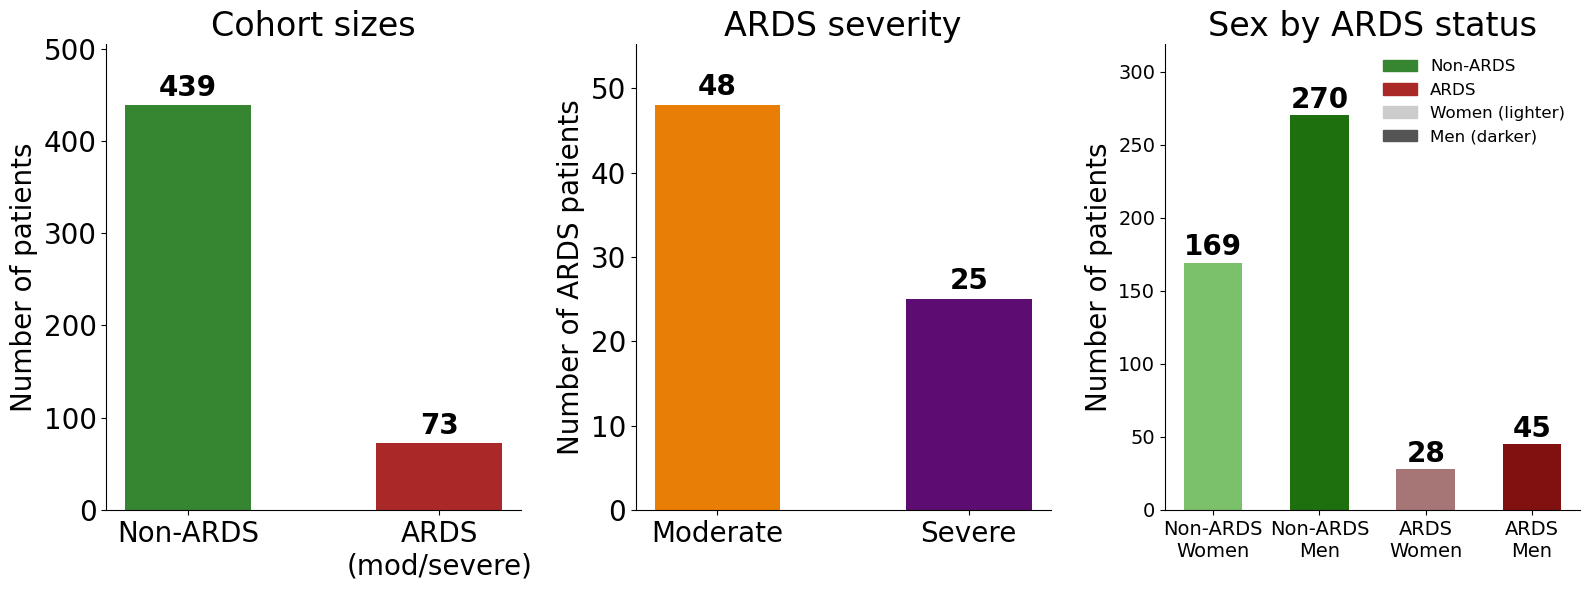

In [54]:
FONTSIZE_TITLE  = 24
FONTSIZE_LABEL  = 20
FONTSIZE_TICK   = 14
FONTSIZE_ANNOT  = 20
FONTSIZE_LEGEND = 12

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#fig.suptitle("Cohort overview", fontsize=FONTSIZE_TITLE, fontweight="bold", x=0.02, ha="left")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Panel A — cohort sizes
ax = axes[0]
bars = ax.bar(["Non-ARDS", "ARDS\n(mod/severe)"], [n_non, n_ards],
              color=[C_NON_ARDS, C_ARDS], width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
            str(int(b.get_height())), ha="center", va="bottom",
            fontweight="bold", fontsize=FONTSIZE_ANNOT)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.set_title("Cohort sizes", fontsize=FONTSIZE_TITLE)
ax.tick_params(axis="both", labelsize=20)
ax.set_ylim(0, n_non * 1.15)

# Panel B — ARDS severity
ax = axes[1]
bars2 = ax.bar(["Moderate", "Severe"], [n_mod, n_sev],
               color=[C_MODERATE, C_SEVERE], width=0.5)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            str(int(b.get_height())), ha="center", va="bottom",
            fontweight="bold", fontsize=FONTSIZE_ANNOT)
ax.set_ylabel("Number of ARDS patients", fontsize=FONTSIZE_LABEL)
ax.set_title("ARDS severity", fontsize=FONTSIZE_TITLE)
ax.tick_params(axis="both", labelsize=20)
ax.set_ylim(0, n_mod * 1.15)

# Panel C — sex by ARDS status
ax = axes[2]
cats   = ["Non-ARDS\nWomen", "Non-ARDS\nMen", "ARDS\nWomen", "ARDS\nMen"]
vals   = [f_non, m_non, f_ards, m_ards]
colors = [C_WOMEN_L, C_MEN_D, C_WOMEN_A, C_MEN_A]
bars3  = ax.bar(cats, vals, color=colors, width=0.55)
for b in bars3:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            str(int(b.get_height())), ha="center", va="bottom",
            fontweight="bold", fontsize=FONTSIZE_ANNOT)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.set_title("Sex by ARDS status", fontsize=FONTSIZE_TITLE)
ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)
ax.set_ylim(0, max(vals) * 1.18)
legend_patches = [
    mpatches.Patch(color=C_NON_ARDS, label="Non-ARDS"),
    mpatches.Patch(color=C_ARDS,     label="ARDS"),
    mpatches.Patch(color="#cccccc",  label="Women (lighter)"),
    mpatches.Patch(color="#555555",  label="Men (darker)"),
]
ax.legend(handles=legend_patches, fontsize=FONTSIZE_LEGEND, frameon=False)

fig.tight_layout()
fig.savefig("../figures/cohort_overview.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [9]:
from matplotlib.gridspec import GridSpec

BINS = 25
ALPHA = 0.6

men_all   = d3[d3['female'] == 0]['age']
women_all = d3[d3['female'] == 1]['age']
men_non   = non_ards[non_ards['female'] == 0]['age']
women_non = non_ards[non_ards['female'] == 1]['age']
men_ard   = ards[ards['female'] == 0]['age']
women_ard = ards[ards['female'] == 1]['age']

mean_all   = d3['age'].mean()
mean_non   = non_ards['age'].mean()
mean_ard   = ards['age'].mean()
mean_men   = men_all.mean()
mean_women = women_all.mean()
mean_non_m = men_non.mean()
mean_non_w = women_non.mean()
mean_ard_m = men_ard.mean()
mean_ard_w = women_ard.mean()

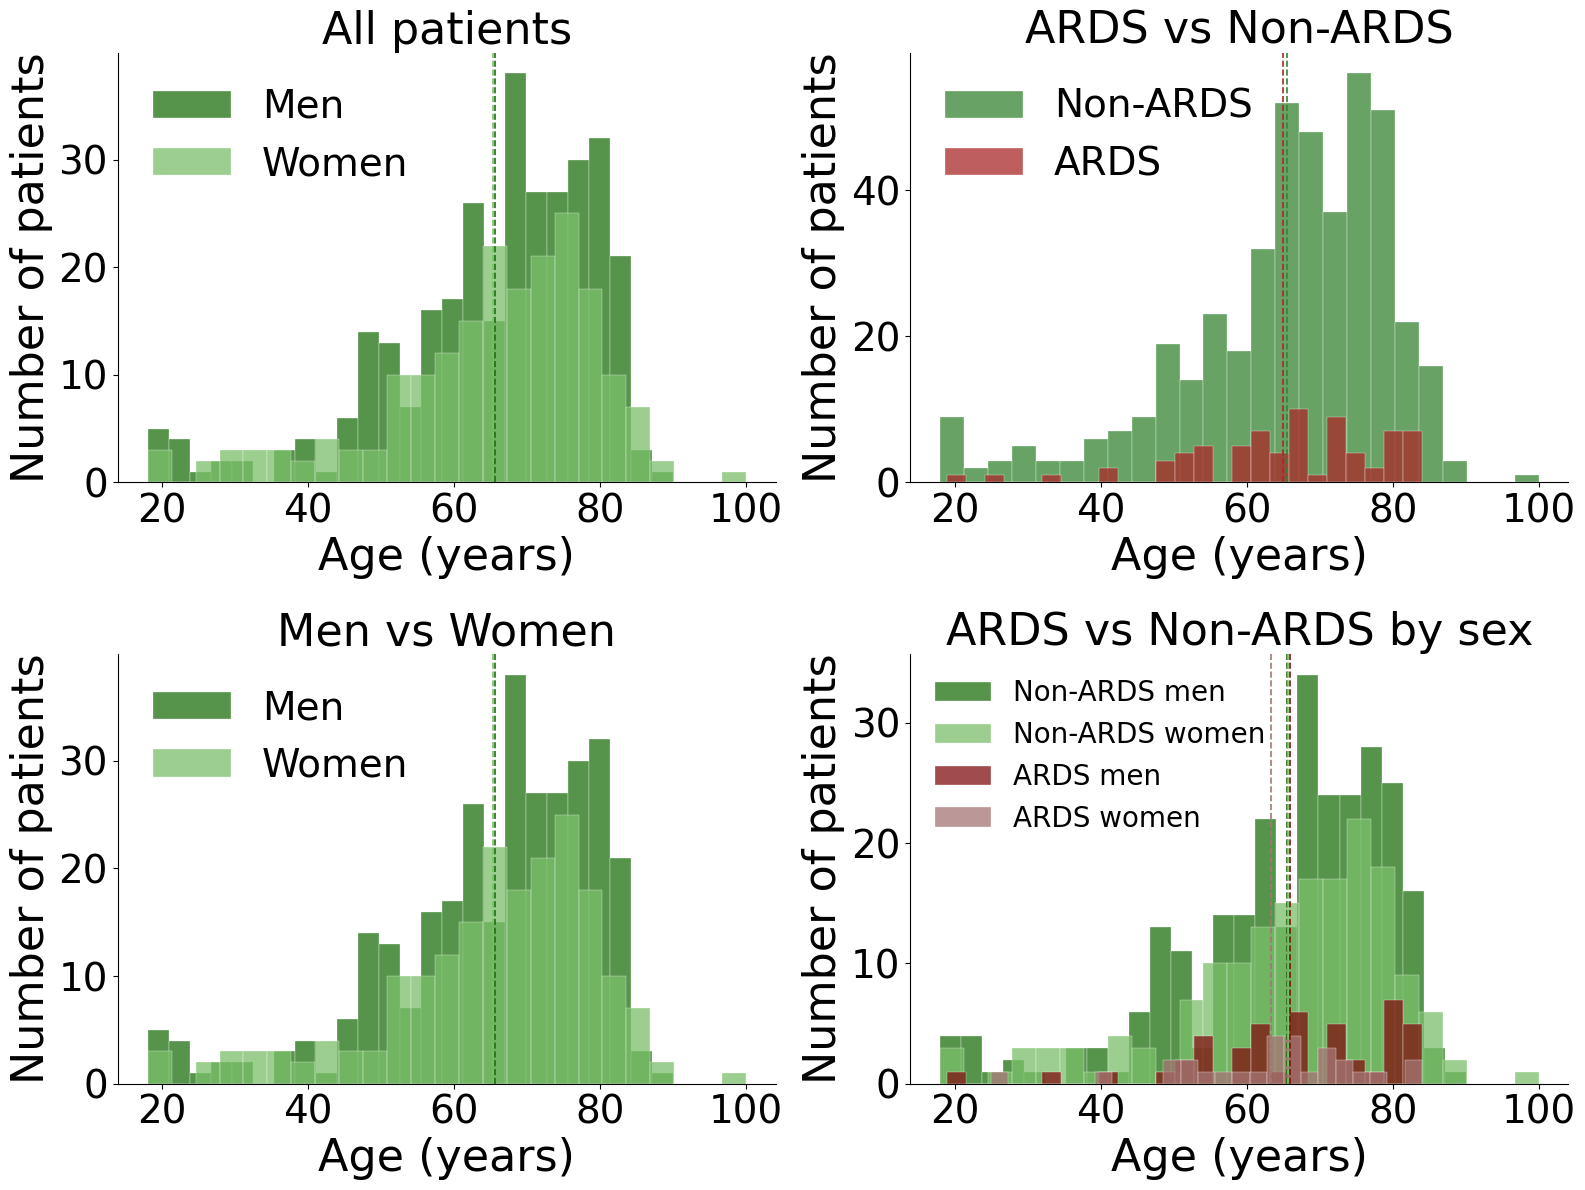

In [110]:
FONTSIZE_TITLE  = 32
FONTSIZE_LABEL  = 32
FONTSIZE_TICK   = 28
FONTSIZE_LEGEND = 28

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def vline(ax, val, color):
    ax.axvline(val, color=color, linestyle="--", linewidth=1.2)

def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)

# (a) All patients
ax = axes[0, 0]
ax.set_title("All patients", fontsize=FONTSIZE_TITLE)
ax.hist(men_all,   bins=BINS, color=C_MEN_D,  alpha=0.75, edgecolor="white", linewidth=0.3, label="Men")
ax.hist(women_all, bins=BINS, color=C_WOMEN_L, alpha=0.75, edgecolor="white", linewidth=0.3, label="Women")
vline(ax, mean_men,   C_MEN_D)
vline(ax, mean_women, C_WOMEN_L)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
style_ax(ax)

# (b) ARDS vs Non-ARDS
ax = axes[0, 1]
ax.set_title("ARDS vs Non-ARDS", fontsize=FONTSIZE_TITLE)
ax.hist(non_ards['age'], bins=BINS, color=C_NON_ARDS, alpha=0.75, edgecolor="white", linewidth=0.3, label="Non-ARDS")
ax.hist(ards['age'],     bins=BINS, color=C_ARDS,     alpha=0.75, edgecolor="white", linewidth=0.3, label="ARDS")
vline(ax, mean_non, C_NON_ARDS)
vline(ax, mean_ard, C_ARDS)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
style_ax(ax)

# (c) Men vs Women
ax = axes[1, 0]
ax.set_title("Men vs Women", fontsize=FONTSIZE_TITLE)
ax.hist(men_all,   bins=BINS, color=C_MEN_D,  alpha=0.75, edgecolor="white", linewidth=0.3, label="Men")
ax.hist(women_all, bins=BINS, color=C_WOMEN_L, alpha=0.75, edgecolor="white", linewidth=0.3, label="Women")
vline(ax, mean_men,   C_MEN_D)
vline(ax, mean_women, C_WOMEN_L)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
style_ax(ax)

# (d) ARDS vs Non-ARDS by sex
ax = axes[1, 1]
ax.set_title("ARDS vs Non-ARDS by sex", fontsize=FONTSIZE_TITLE)
ax.hist(men_non,   bins=BINS, color=C_MEN_D,  alpha=0.75, edgecolor="white", linewidth=0.3, label="Non-ARDS men")
ax.hist(women_non, bins=BINS, color=C_WOMEN_L, alpha=0.75, edgecolor="white", linewidth=0.3, label="Non-ARDS women")
ax.hist(men_ard,   bins=BINS, color=C_MEN_A,  alpha=0.75, edgecolor="white", linewidth=0.3, label="ARDS men")
ax.hist(women_ard, bins=BINS, color=C_WOMEN_A, alpha=0.75, edgecolor="white", linewidth=0.3, label="ARDS women")
for val, col in [(mean_non_m, C_MEN_D), (mean_non_w, C_WOMEN_L),
                 (mean_ard_m, C_MEN_A),  (mean_ard_w, C_WOMEN_A)]:
    vline(ax, val, col)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE_LABEL)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.legend(fontsize=20, frameon=False)
style_ax(ax)

fig.tight_layout()
fig.subplots_adjust(hspace=0.4)  # öka värdet för mer mellanrum
fig.savefig("../figures/age_dists.pdf", bbox_inches="tight", dpi=300)
plt.show()

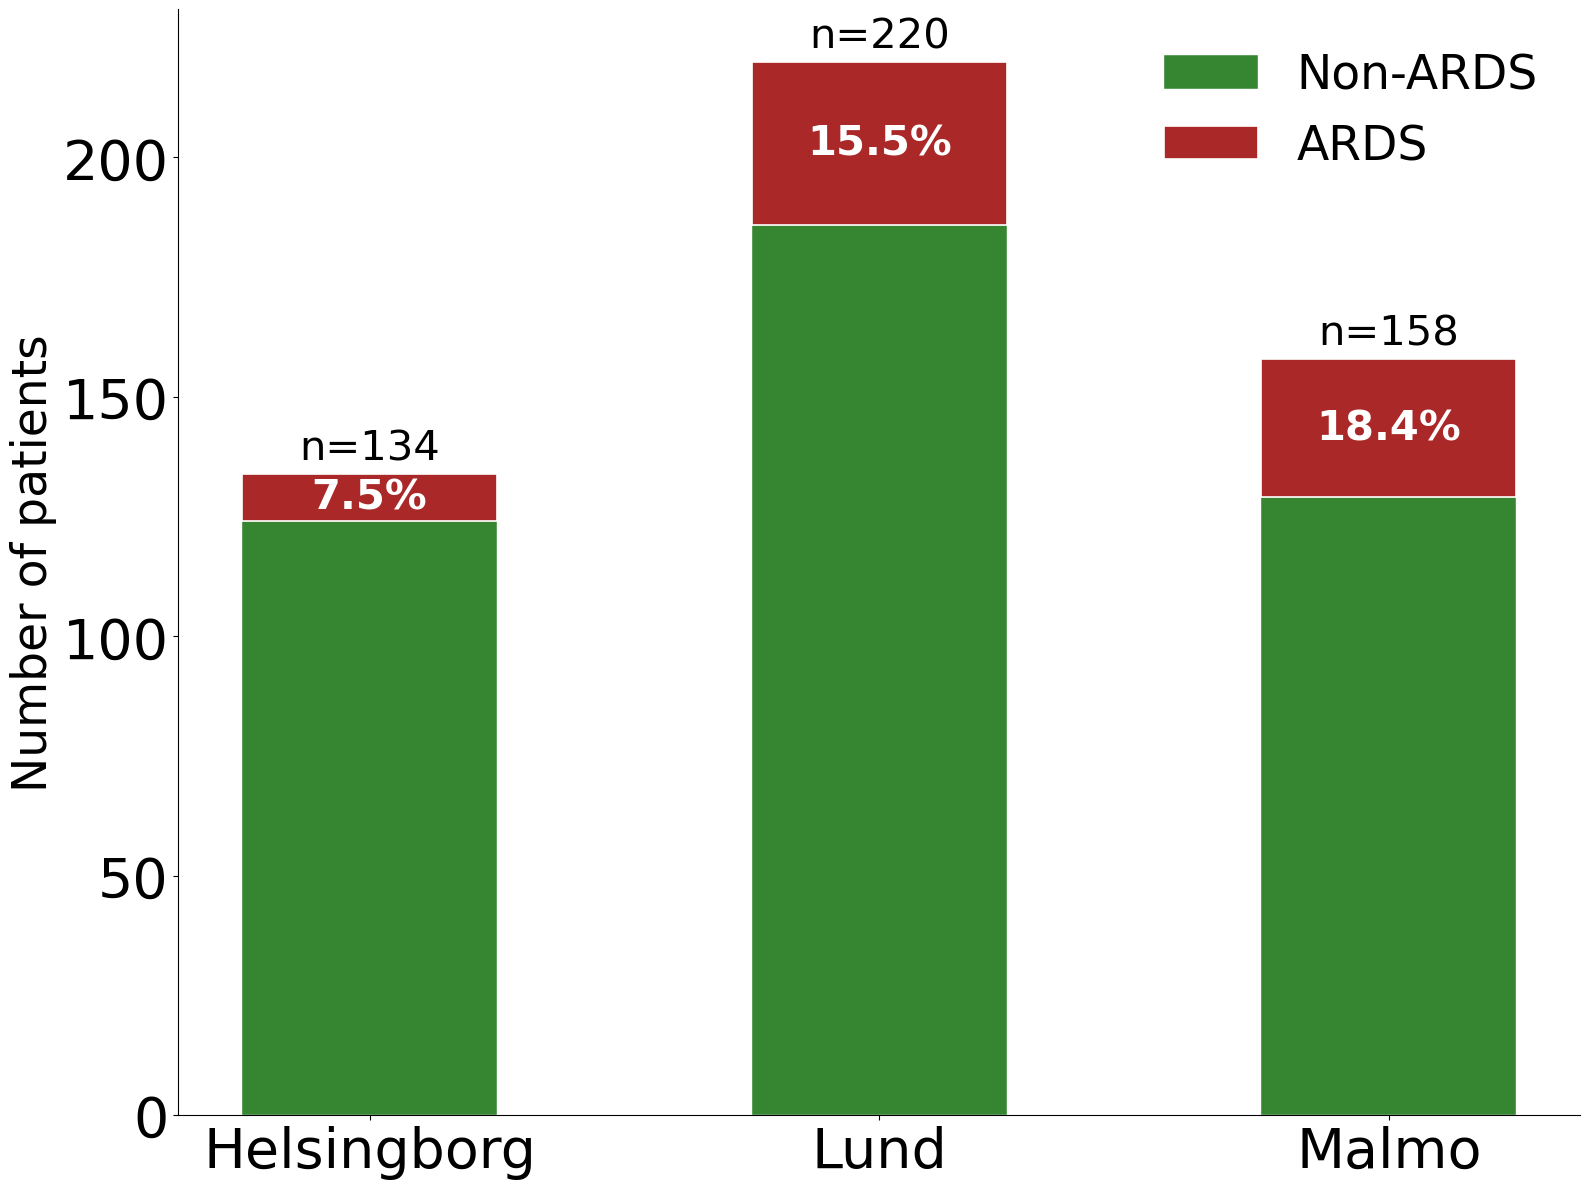

In [97]:
FONTSIZE_TITLE  = 34
FONTSIZE_LABEL  = 34
FONTSIZE_TICK   = 40
FONTSIZE_LEGEND = 34
FONTSIZE_ANNOT  = 30

fig, ax = plt.subplots(figsize=(16, 12))
#ax.set_title("Patient distribution across ICU sites", fontsize=FONTSIZE_TITLE)

sites   = sorted(d3['IVAavd'].dropna().unique())
n_non_s = [len(non_ards[non_ards['IVAavd'] == s]) for s in sites]
n_ard_s = [len(ards[ards['IVAavd'] == s])         for s in sites]
n_tot_s = [a + b for a, b in zip(n_non_s, n_ard_s)]
x = np.arange(len(sites))

ax.bar(x, n_non_s, width=0.5, color=C_NON_ARDS, label="Non-ARDS", edgecolor="white", linewidth=0.3)
ax.bar(x, n_ard_s, width=0.5, bottom=n_non_s,   color=C_ARDS,     label="ARDS",     edgecolor="white", linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(sites, fontsize=FONTSIZE_TICK)
ax.tick_params(axis="y", labelsize=FONTSIZE_TICK)
ax.set_ylabel("Number of patients", fontsize=FONTSIZE_LABEL)
ax.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, (na, a, tot) in enumerate(zip(n_non_s, n_ard_s, n_tot_s)):
    ax.text(i, tot + 1, f"n={tot}", ha="center", va="bottom", fontsize=FONTSIZE_ANNOT)
    ax.text(i, na + a/2, f"{a/tot*100:.1f}%", ha="center", va="center",
            fontsize=FONTSIZE_ANNOT, color="white", fontweight="bold")

fig.tight_layout()
fig.savefig("../figures/icu_dists.pdf", bbox_inches="tight", dpi=300)
plt.show()

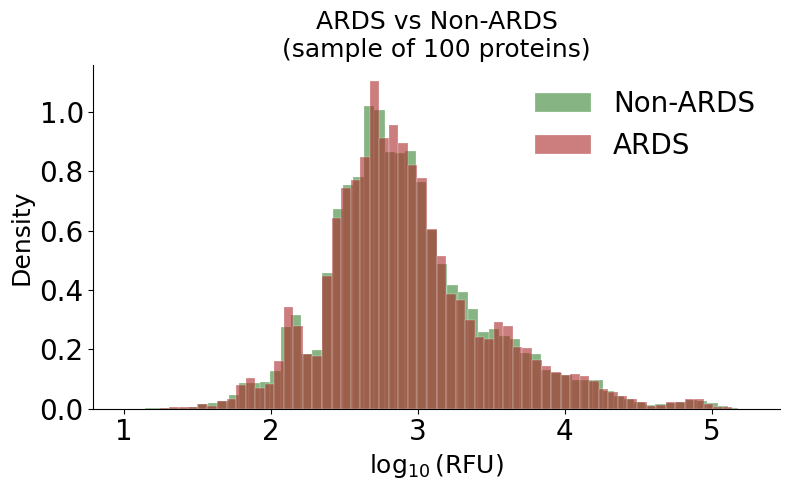

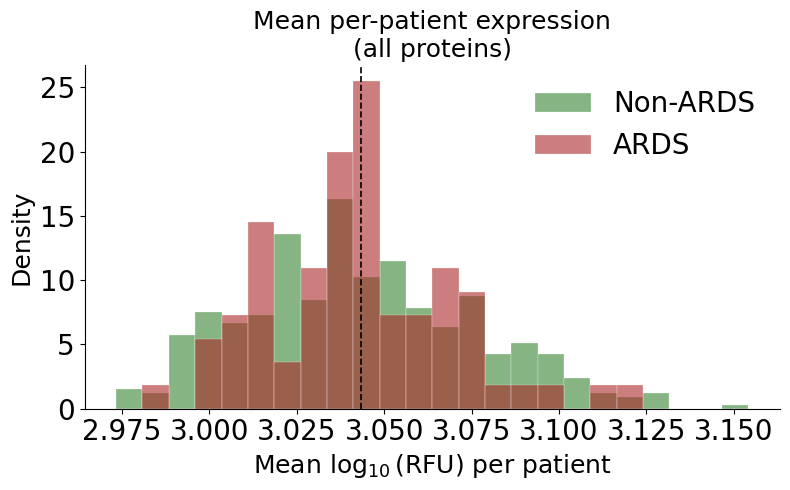

In [107]:
FONTSIZE_TITLE  = 18
FONTSIZE_LABEL  = 18
FONTSIZE_TICK   = 20
FONTSIZE_LEGEND = 20

import json
with open('../data/processed/protein_ids.json', 'r') as f:
    protein_ids = json.load(f)

cohort    = pd.read_parquet('../data/processed/cohort.parquet')
ards_mask = cohort['y'].values == 1
prot_df   = cohort[protein_ids]
log_prot  = prot_df

def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=FONTSIZE_TICK)

# ── Plot 1 — ARDS vs Non-ARDS ─────────────────────────────────────────────────
sample_100 = protein_ids[:100]
lp_non = log_prot.loc[~ards_mask, sample_100].values.ravel()
lp_ard = log_prot.loc[ards_mask,  sample_100].values.ravel()
lp_non = lp_non[np.isfinite(lp_non)]
lp_ard = lp_ard[np.isfinite(lp_ard)]

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.hist(lp_non, bins=60, color=C_NON_ARDS, alpha=0.6, density=True,
         edgecolor="white", linewidth=0.3, label="Non-ARDS")
ax1.hist(lp_ard, bins=60, color=C_ARDS,     alpha=0.6, density=True,
         edgecolor="white", linewidth=0.3, label="ARDS")
ax1.set_xlabel(r"$\log_{10}(\mathrm{RFU})$", fontsize=FONTSIZE_LABEL)
ax1.set_ylabel("Density", fontsize=FONTSIZE_LABEL)
ax1.set_title(f"ARDS vs Non-ARDS\n(sample of {len(sample_100)} proteins)",
              fontsize=FONTSIZE_TITLE)
ax1.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
style_ax(ax1)
fig1.tight_layout()
fig1.savefig("../figures/value_dist_ards_vs_nonards.pdf", bbox_inches="tight", dpi=300)
plt.show()

# ── Plot 2 — Mean per-patient expression ──────────────────────────────────────
mean_per_patient = log_prot.mean(axis=1)
mn_non     = mean_per_patient[~ards_mask]
mn_ard     = mean_per_patient[ards_mask]
grand_mean = mean_per_patient.mean()
bins_c     = np.linspace(mean_per_patient.min(), mean_per_patient.max(), 25)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(mn_non, bins=bins_c, color=C_NON_ARDS, alpha=0.6, density=True,
         edgecolor="white", linewidth=0.3, label="Non-ARDS")
ax2.hist(mn_ard, bins=bins_c, color=C_ARDS,     alpha=0.6, density=True,
         edgecolor="white", linewidth=0.3, label="ARDS")
ax2.axvline(grand_mean, color="black", linestyle="--", linewidth=1.2)
ax2.set_xlabel(r"Mean $\log_{10}(\mathrm{RFU})$ per patient", fontsize=FONTSIZE_LABEL)
ax2.set_ylabel("Density", fontsize=FONTSIZE_LABEL)
ax2.set_title("Mean per-patient expression\n(all proteins)", fontsize=FONTSIZE_TITLE)
ax2.legend(fontsize=FONTSIZE_LEGEND, frameon=False)
style_ax(ax2)
fig2.tight_layout()
fig2.savefig("../figures/value_dist_mean_per_patient.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [13]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import sys

# Färgpalett
ARDS_COLOR = '#003844'      # dark teal
NON_ARDS_COLOR = '#FFB100'  # amber flame
ACCENT = '#F194B4'          # pink mist
BEIGE = '#FFEBC6'           # pearl beige

ards_mask = cohort['y'].values == True

# Protein expression matrix — justera path efter din struktur
X = pd.read_parquet('../data/processed/cohort.parquet')
protein_cols = [c for c in X.columns if c.startswith('seq.')]

In [14]:
anno = pd.read_csv('../data/processed/somalogic_annotation.csv')
print(anno.columns.tolist())
print(anno.head(2))

['PROBEID', 'SYMBOL', 'UNIPROT', 'ENTREZID', 'GENENAME']
    PROBEID  SYMBOL     UNIPROT  ENTREZID  \
0  10000-28  CRYBB2  A0A0H3W5U0    1415.0   
1   10001-7    RAF1  A0A0S2Z559    5894.0   

                                        GENENAME  
0                             crystallin beta B2  
1  Raf-1 proto-oncogene, serine/threonine kinase  


In [15]:
symbol_to_seq = {
    'SDHAF2':  'seq.26103.20',
    'BLOC1S2': 'seq.21184.1',
    'ALDH5A1': 'seq.17792.158',
    'GOLM1':   'seq.17456.53',
    'MAFF':    'seq.31598.17',
    'COX5B':   'seq.7887.57',
    'AGER':    'seq.4125.52',   # ← ändrad
    'MFAP5':   'seq.6440.20',   # ← ändrad
    'STAT1':   'seq.10370.21',
    'CHCHD10': 'seq.11270.17',
    'KIR2DS2': 'seq.10428.1',
    'HDGFL1':  'seq.18898.36',
}

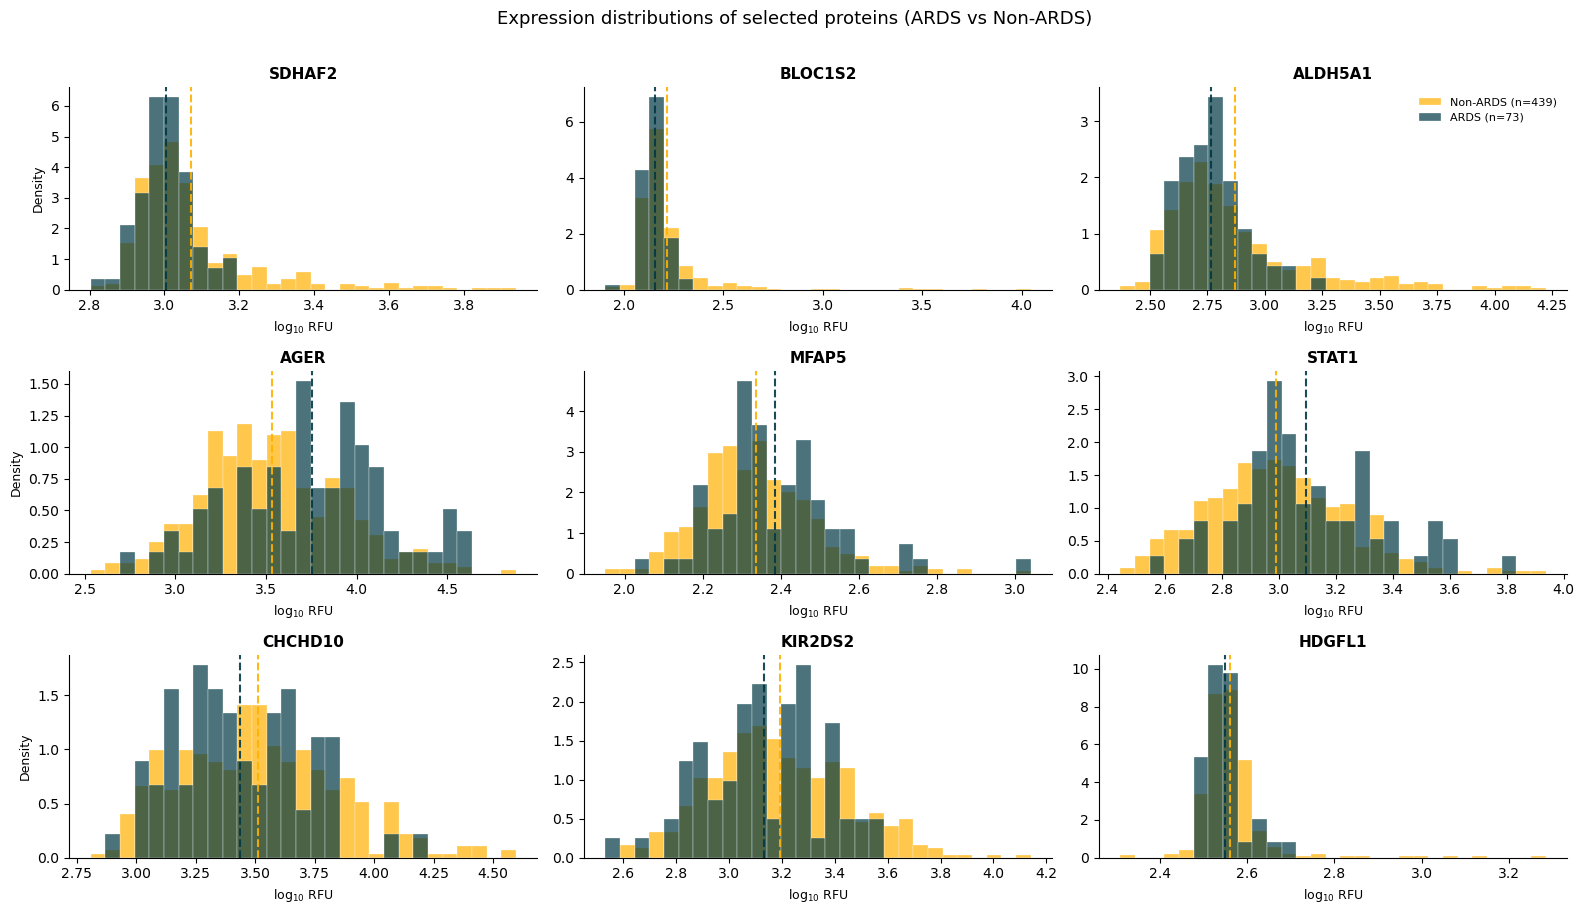

In [16]:
all_proteins = ['SDHAF2', 'BLOC1S2', 'ALDH5A1',
                'AGER',   'MFAP5',   'STAT1',
                'CHCHD10','KIR2DS2', 'HDGFL1']

n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))

for idx, (ax, protein) in enumerate(zip(axes.flatten(), all_proteins)):
    seq = symbol_to_seq[protein]

    vals_ards     = X.loc[ards_mask,  seq].values
    vals_non_ards = X.loc[~ards_mask, seq].values

    bins = np.linspace(
        min(vals_ards.min(), vals_non_ards.min()),
        max(vals_ards.max(), vals_non_ards.max()),
        30
    )

    ax.hist(vals_non_ards, bins=bins, density=True, alpha=0.7,
            color=NON_ARDS_COLOR, edgecolor='white', linewidth=0.3,
            label=f'Non-ARDS (n={len(vals_non_ards)})')
    ax.hist(vals_ards, bins=bins, density=True, alpha=0.7,
            color=ARDS_COLOR, edgecolor='white', linewidth=0.3,
            label=f'ARDS (n={len(vals_ards)})')

    ax.axvline(np.mean(vals_non_ards), color=NON_ARDS_COLOR,
               linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axvline(np.mean(vals_ards), color=ARDS_COLOR,
               linestyle='--', linewidth=1.5, alpha=0.9)

    ax.set_title(protein, fontsize=11, fontweight='bold')
    ax.set_xlabel('log$_{10}$ RFU', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

    if idx % n_cols == 0:
        ax.set_ylabel('Density', fontsize=9)

    if idx == 2:
        ax.legend(frameon=False, fontsize=8)

plt.suptitle('Expression distributions of selected proteins (ARDS vs Non-ARDS)',
             fontsize=13, y=1.01)
plt.tight_layout()

plt.show()

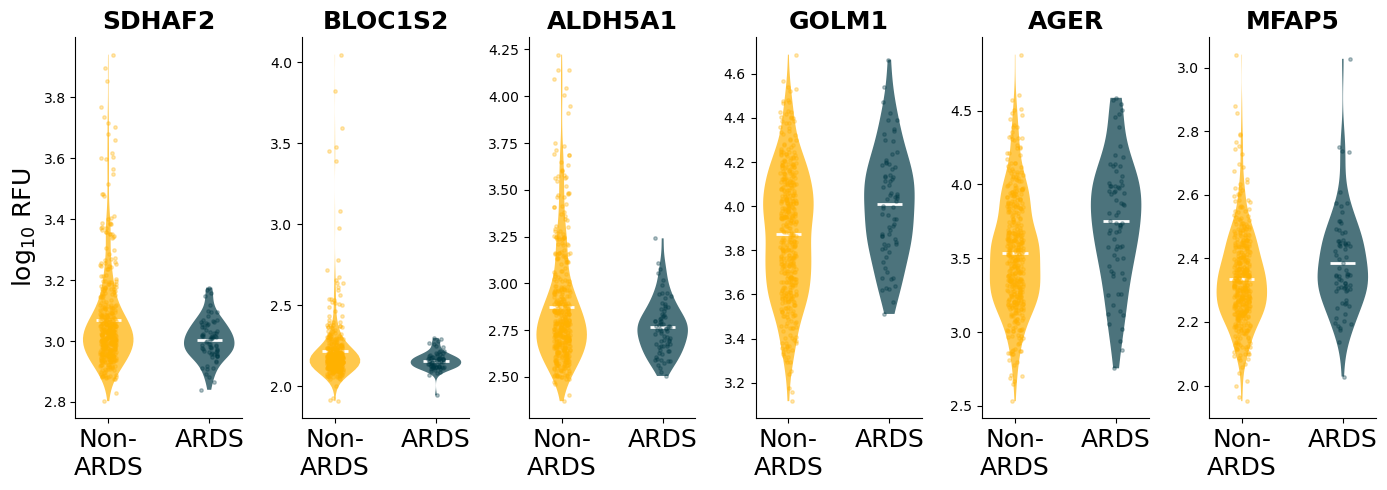

In [ ]:
# Cell 3: Violinplot — panel med topproteiner från t-test + RF
# Visar att separation ser olika ut för olika proteiner

proteins_to_plot = ['SDHAF2', 'BLOC1S2', 'ALDH5A1', 'GOLM1', 'AGER', 'MFAP5']

fig, axes = plt.subplots(1, len(proteins_to_plot), figsize=(14, 5), sharey=False)
np.random.seed(42)  # lägg till innan loopen
for ax, protein in zip(axes, proteins_to_plot):
    seq = symbol_to_seq[protein]
    data_non = X.loc[~ards_mask, seq].values
    data_ards = X.loc[ards_mask,  seq].values

    parts = ax.violinplot([data_non, data_ards], positions=[0, 1],
                          showmeans=True, showextrema=False)

    parts['bodies'][0].set_facecolor(NON_ARDS_COLOR)
    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor(ARDS_COLOR)
    parts['bodies'][1].set_alpha(0.7)
    parts['cmeans'].set_color('white')
    parts['cmeans'].set_linewidth(2)

    # Jitter-punkter
    for i, (vals, col) in enumerate([(data_non, NON_ARDS_COLOR), (data_ards, ARDS_COLOR)]):
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, color=col, alpha=0.3, s=6, zorder=2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-\nARDS', 'ARDS'], fontsize=18)
    ax.set_title(protein, fontsize=18, fontweight='bold', loc='center')
    ax.spines[['top', 'right']].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('log$_{10}$ RFU', fontsize=18)

#plt.suptitle('Individual protein expression distributions', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig("../figures/individual_prot.pdf", bbox_inches="tight", dpi=300)
plt.show()

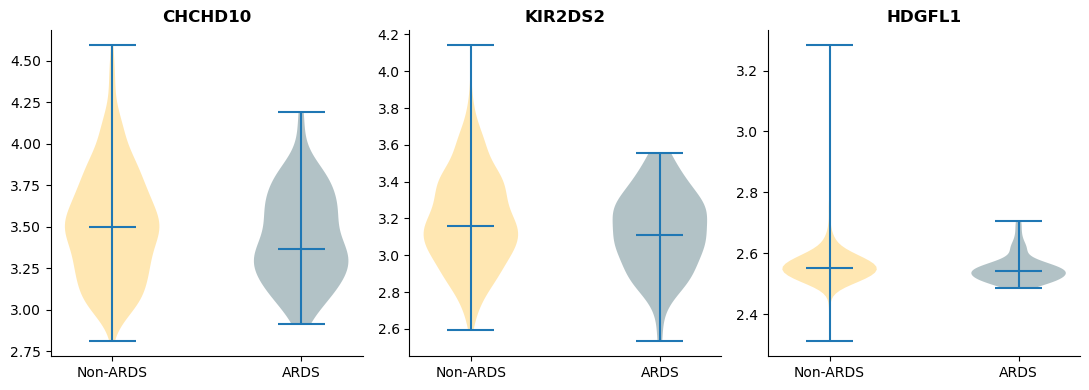

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, protein in zip(axes, ['CHCHD10', 'KIR2DS2', 'HDGFL1']):
    seq = symbol_to_seq[protein]
    vals_ards     = X.loc[ards_mask,  seq].values
    vals_non_ards = X.loc[~ards_mask, seq].values
    parts = ax.violinplot([vals_non_ards, vals_ards],
                          positions=[0, 1], showmedians=True)
    parts['bodies'][0].set_facecolor(NON_ARDS_COLOR)
    parts['bodies'][1].set_facecolor(ARDS_COLOR)
    ax.set_title(protein, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-ARDS', 'ARDS'])
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

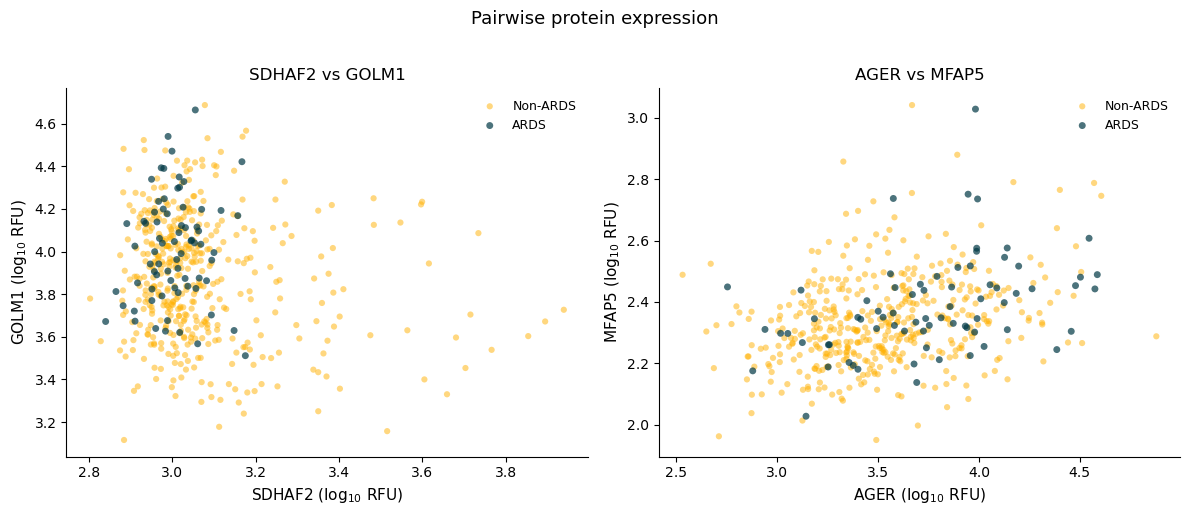

In [19]:
# Cell 4: Scatterplot — två proteiner mot varandra
# Mest intressant: ett par som INTE separerar individuellt men KAN göra det tillsammans
# Bra kandidat: GOLM1 (positiv score) vs SDHAF2 (negativ score) — olika riktning

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pairs = [
    ('SDHAF2', 'GOLM1'),   # Intressant: en går upp, en går ner i ARDS
    ('AGER',   'MFAP5'),   # RF-toppar
]

for ax, (p1, p2) in zip(axes, pairs):
    s1 = symbol_to_seq[p1]
    s2 = symbol_to_seq[p2]

    ax.scatter(X.loc[~ards_mask, s1], X.loc[~ards_mask, s2],
               color=NON_ARDS_COLOR, alpha=0.5, s=20, label='Non-ARDS',
               edgecolors='none')
    ax.scatter(X.loc[ards_mask, s1], X.loc[ards_mask, s2],
               color=ARDS_COLOR, alpha=0.7, s=25, label='ARDS',
               edgecolors='none')

    ax.set_xlabel(f'{p1} (log$_{{10}}$ RFU)', fontsize=11)
    ax.set_ylabel(f'{p2} (log$_{{10}}$ RFU)', fontsize=11)
    ax.set_title(f'{p1} vs {p2}', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

plt.suptitle('Pairwise protein expression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

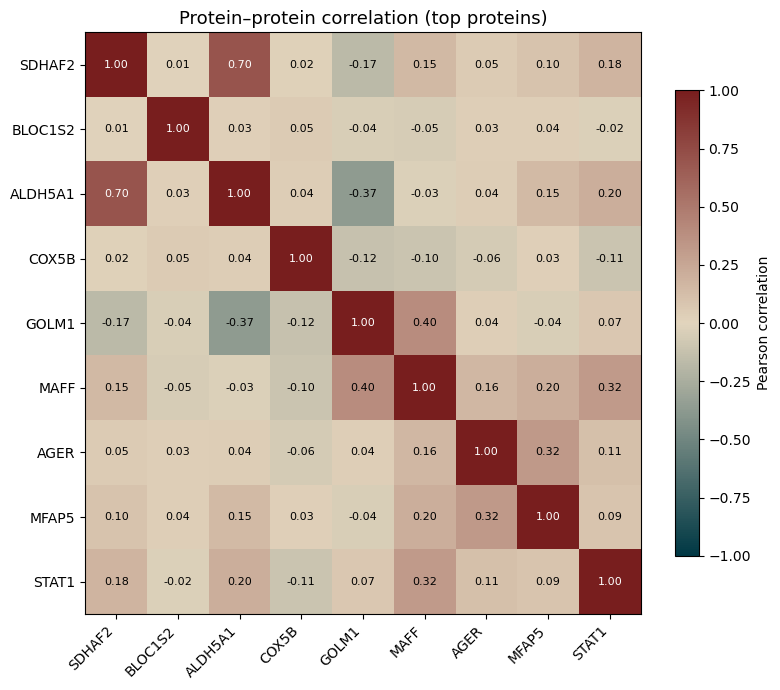

In [20]:
# Cell 5: Korrelationsheatmap — topproteiner
# Visar vilka proteiner som samvarierar (redundanta) vs unika

proteins_heatmap = ['SDHAF2', 'BLOC1S2', 'ALDH5A1', 'COX5B',
                    'GOLM1', 'MAFF', 'AGER', 'MFAP5', 'STAT1']
seqs = [symbol_to_seq[p] for p in proteins_heatmap]

corr = X[seqs].corr()
corr.index = proteins_heatmap
corr.columns = proteins_heatmap

fig, ax = plt.subplots(figsize=(8, 7))

# Färgkarta: divergerande från teal till beige till mörkröd
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'custom', ['#003844', "#E2D5BD", '#781E1E'], N=256
)

im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(proteins_heatmap)))
ax.set_yticks(range(len(proteins_heatmap)))
ax.set_xticklabels(proteins_heatmap, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(proteins_heatmap, fontsize=10)

# Lägg till värden i cellerna
for i in range(len(proteins_heatmap)):
    for j in range(len(proteins_heatmap)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')
ax.set_title('Protein–protein correlation (top proteins)', fontsize=13)
plt.tight_layout()
plt.show()

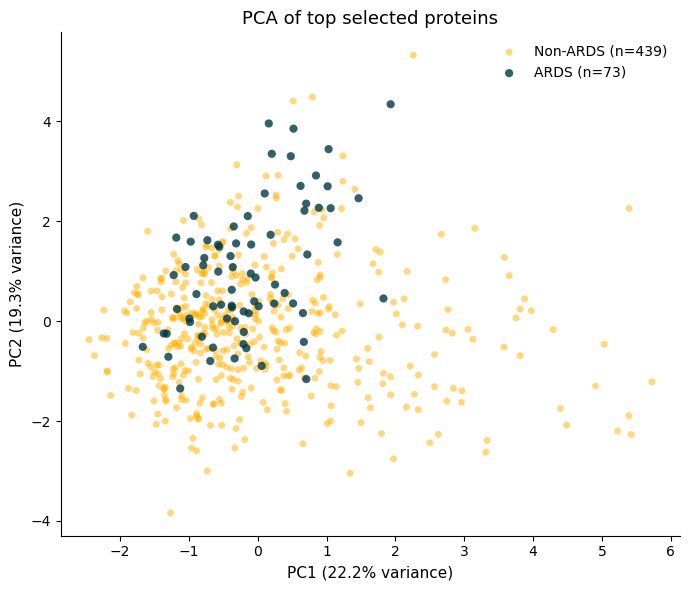

In [21]:
# Cell 6: PCA — topproteinerna tillsammans
# Det roliga: visar om proteinerna TILLSAMMANS separerar grupperna
# även om de inte gör det individuellt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

seqs_pca = [symbol_to_seq[p] for p in proteins_heatmap]
X_sub = X[seqs_pca].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(X_pca[~ards_mask, 0], X_pca[~ards_mask, 1],
           color=NON_ARDS_COLOR, alpha=0.5, s=25,
           label=f'Non-ARDS (n={(~ards_mask).sum()})', edgecolors='none')
ax.scatter(X_pca[ards_mask, 0], X_pca[ards_mask, 1],
           color=ARDS_COLOR, alpha=0.8, s=35,
           label=f'ARDS (n={ards_mask.sum()})', edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA of top selected proteins', fontsize=13)
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.show()

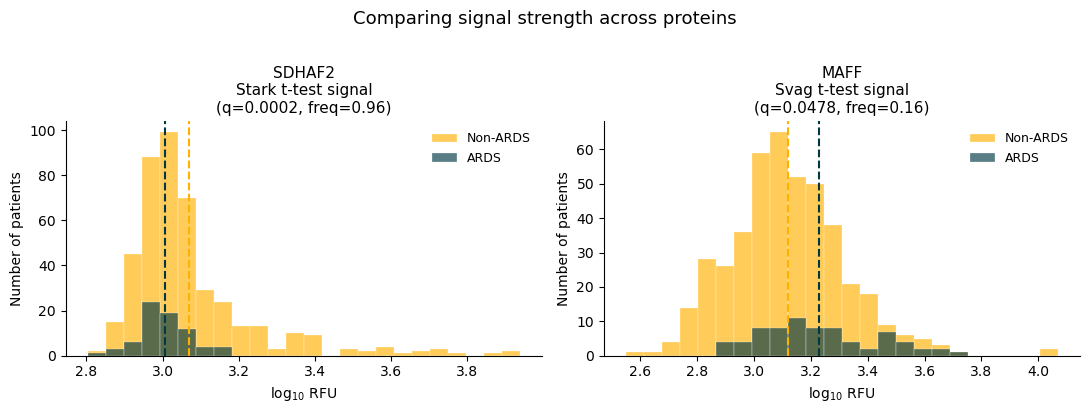

In [22]:
# Cell 7: "Intressant extra" — visa ett protein med hög MI men låg t-test score
# dvs ett protein som INTE syns i t-test men fångas av MI
# Lägg till MI-topproteiner här när du har dem, t.ex:
# mi_top = {'PROTEIN_X': 'seq.XXXXX.XX'}
# Ersätt nedan med ditt MI-toppprotein

# Exempel på hur du kan visa en "missad" signal:
# Två panels: t-test signifikant vs MI signifikant men inte t-test
# För nu: placeholder med MAFF som har låg resample freq men positiv score

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

examples = [
    ('SDHAF2', 'Stark t-test signal\n(q=0.0002, freq=0.96)'),
    ('MAFF',   'Svag t-test signal\n(q=0.0478, freq=0.16)'),
]

for ax, (protein, subtitle) in zip(axes, examples):
    seq = symbol_to_seq[protein]
    data_non = X.loc[~ards_mask, seq].values
    data_ards = X.loc[ards_mask,  seq].values

    bins = np.linspace(
        min(data_non.min(), data_ards.min()),
        max(data_non.max(), data_ards.max()),
        25
    )
    ax.hist(data_non, bins=bins, alpha=0.65, color=NON_ARDS_COLOR,
            edgecolor='white', linewidth=0.3, label='Non-ARDS')
    ax.hist(data_ards, bins=bins, alpha=0.65, color=ARDS_COLOR,
            edgecolor='white', linewidth=0.3, label='ARDS')

    ax.axvline(np.mean(data_non), color=NON_ARDS_COLOR,
               linestyle='--', linewidth=1.5)
    ax.axvline(np.mean(data_ards), color=ARDS_COLOR,
               linestyle='--', linewidth=1.5)

    ax.set_title(f'{protein}\n{subtitle}', fontsize=11)
    ax.set_xlabel('log$_{10}$ RFU', fontsize=10)
    ax.set_ylabel('Number of patients', fontsize=10)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Comparing signal strength across proteins', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()